# One single-shot pass over NL2RepoBench: what it scored, and what it consumed

Job `2026-09-04__22-49-39` is 104 trials — every task in the benchmark, once each, one
model, one request per task, no agent loop. That shape is the point: whatever this run
scores is the floor a more elaborate method has to beat, and whatever it consumes is the
budget line a more elaborate method has to justify.

This notebook reads the job directory as it stands on disk and asks four things of it:

1. **What did it score?** — the reward distribution, and how it moves with difficulty.
2. **Where did the tokens go?** — how often the reply stopped at the output ceiling,
   and whether that ceiling actually costs anything.
3. **What did the tokens buy?** — tokens per trial against reward earned.
4. **How did the zeros happen?** — a zero from failing tests and a zero from an
   unimportable package are different findings, and the verifier logs tell them apart.

Nothing here is re-run or re-scored; every number is read from the files the job wrote.
This is one of three run notebooks that share a reader and a set of figures, and it
makes **no comparison between the arms** — that is a separate exercise once every arm
has been run.

## 1. Parameters

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# --- what to read ------------------------------------------------------------
JOB = "2026-09-04__22-49-39"

# Reward at or above which a task counts as solved rather than partially credited.
# Not 1.0: a run that passes 95% of a package's hidden tests has produced a working
# package, and calling that a failure would flatter every method equally. Every
# other threshold this notebook uses is a budget, and those are read from each
# trial's own configuration rather than restated here.
SOLVED_AT = 0.9

# Figures are prefixed so the arms' figures sit beside each other in docs/figures
# without overwriting one another.
FIGURE_PREFIX = "single-shot"

# `job_analysis` and `job_figures` live beside the notebooks. Jupyter puts the
# notebook's own directory on the path; this covers a kernel started elsewhere.
NOTEBOOKS = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
if str(NOTEBOOKS) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS))

import matplotlib.pyplot as plt

import job_analysis as ja
import job_figures as jf

jf.use_house_style()
save = jf.saver(FIGURE_PREFIX)

df = ja.load_job(JOB, solved_at=SOLVED_AT)
print(f"job     : {ja.job_path(JOB)}")
print(f"arm     : {df.attrs['arm'].name}")
print(f"budget  : {df.attrs['arm'].budget_name} = {df.attrs['budget']}")
print(f"solved  : reward >= {SOLVED_AT}")
print()
print(ja.headline(df))
print()
print(df.outcome.value_counts().to_string())

job     : C:\Code\EvaluationPlatform\jobs\2026-09-04__22-49-39
arm     : single-shot
budget  : max_tokens = 131100
solved  : reward >= 0.9

trials          : 104
mean reward     : 0.162   median 0.000   (n=104)
total tokens    : 7.3M  (14% of input served from cache)
total wall clock: 10.1 h summed over trials

outcome
partial credit      40
never imported      36
ran, all failed     11
never configured    11
no verdict           3
solved               3


## 2. Conventions

Two rules govern every figure, and both live in `job_figures` rather than being
restated per notebook.

**Ordered variables get ordered ramps.** Difficulty, token quartile and failure stage
are all ordered, so each gets one hue running light to dark rather than a set of
arbitrary colours. Where none of them is the subject, grey is context and blue is the
thing being shown; red is reserved for the one thing a figure is warning about.

**Text on a figure is a title, an axis word, and direct labels on the marks.** The
strings for the shared figures are in `jf.FIGURE_TEXT` and every one of them takes a
`text=` override, so re-wording a chart never means touching plotting code. Titles that
quote a number are format strings filled from the data at draw time, so they cannot go
stale when `JOB` changes. The cell below holds the same thing for the figures that only
this notebook draws.

In [2]:
import matplotlib.pyplot as plt

# The figures only this notebook draws. Everything else is `jf.FIGURE_TEXT`.
TEXT = {
    "ceiling": dict(
        title="{n_trunc} replies stop at the output ceiling",
        x="", y="output tokens", note="ceiling",
    ),
    "truncation": dict(
        title="The ceiling only costs anything on Hard",
        x="", y="mean reward",
        series={False: "within ceiling", True: "at ceiling"},
    ),
}

## 3. Reading the job directory

`ja.load_job` returns one row per trial. Its shared half — reward, tokens,
timings, the pytest summary, and the reason behind every flat zero — is read the same
way for every arm, so a cause counted here means what it means in the other run
notebooks. `ja.COMMON_COLUMNS` is that contract; anything else on the frame is this
arm's own, listed in its `ja.ARMS` entry.

What this arm records on top is the reply itself: the size of the prompt, the number of
files the runner parsed out of the answer, and its complaints when a file block was
malformed — `w_unclosed`, `w_empty`, `w_dupe`, `w_nofence` — plus `looped`, the runner's
own verdict on a truncated reply that had stopped saying anything new.

The budget here is `max_tokens`, so `hit_budget` means the reply was cut off mid-file
rather than finished.

## 4. What the run scored

The mean reward is the number that would go in a table, and on its own it is misleading
in both directions. Below it, most trials scored nothing at all; above it, a handful
reproduced a package almost exactly. Ranking every trial rather than binning them shows
both, without a choice of bin width doing any of the arguing.

wrote docs\figures\single-shot-reward-ranked.png

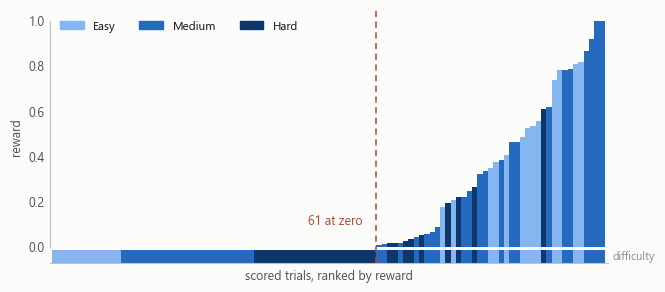

            trials at zero  scored trials  share of the level
difficulty                                                   
Easy                    13             26                0.50
Medium                  25             46                0.54
Hard                    23             32                0.72


In [3]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.reward_ranked(df), "reward-ranked")
plt.show()

print(ja.zero_rate(df).round(2).to_string())

Ties are broken by level, so the rug's zero block reads as three measurable segments:
Hard fills more of it than its 32-in-104 share of the benchmark, and the counts printed
under the figure give the rate directly.

Difficulty is the benchmark's own label, assigned from lines of code before any model
saw the task, so the gradient below is less a finding about this run than a check that
the run behaves the way the label says it should — steeply.

wrote docs\figures\single-shot-reward-by-difficulty.png


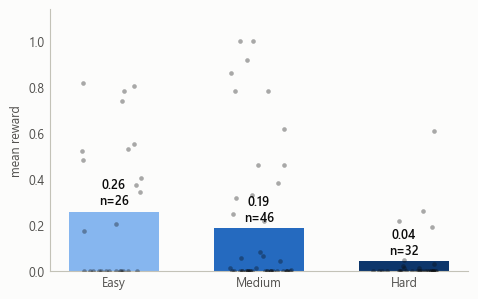

In [4]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.reward_by_difficulty(df), "reward-by-difficulty")
plt.show()

## 5. The output ceiling

The agent gets one request, so the whole repository has to fit in one reply. A reply
whose output token count reaches `max_tokens` exactly was cut off mid-file rather than
finished. Worth separating from a wrong answer: a truncated repository fails to import,
and an import failure scores zero for a reason that has nothing to do with whether the
model understood the task.

wrote docs\figures\single-shot-output-ceiling.png


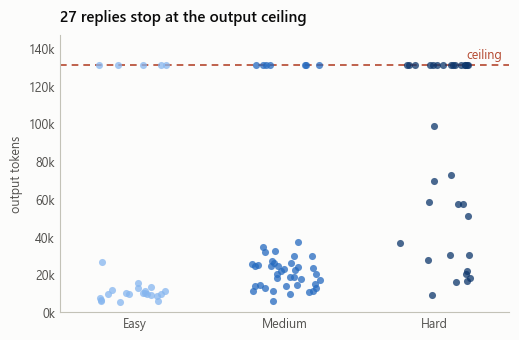

at the ceiling      : 27 of 104 trials (26%)
                      47% of the 32 Hard tasks
share of all output : 67% of the run's output tokens
degenerate loops    : 5 of those replies repeated themselves rather than needing the room


In [5]:
import numpy as np

df = ja.load_job(JOB, solved_at=SOLVED_AT)
t = TEXT["ceiling"]
ceiling = df.budget_value.iloc[0]
rng = np.random.default_rng(0)   # jitter only

fig, ax = plt.subplots(figsize=(5.8, 3.6))
for i, level in enumerate(ja.LEVELS):
    points = df.loc[df.difficulty == level, "out_tok"]
    ax.scatter(
        i + rng.uniform(-0.24, 0.24, len(points)), points,
        s=26, color=jf.BAND_COLOR[level], alpha=0.75, linewidth=0, zorder=3,
    )
ax.axhline(ceiling, color=jf.ALERT, linestyle=(0, (4, 3)), linewidth=1.2, zorder=2)
ax.annotate(
    t["note"], xy=(len(ja.LEVELS) - 0.55, ceiling), xytext=(0, 5),
    textcoords="offset points", color=jf.ALERT, ha="right", fontsize=9,
)

ax.set_title(t["title"].format(n_trunc=int(df.hit_budget.sum())))
ax.set_ylabel(t["y"])
ax.set_xticks(range(len(ja.LEVELS)))
ax.set_xticklabels(ja.LEVELS)
ax.set_xlim(-0.5, len(ja.LEVELS) - 0.5)
ax.set_ylim(0, ceiling * 1.12)
ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:.0f}k")
jf.tidy(ax)
save(fig, "output-ceiling")
plt.show()

hit = df[df.hit_budget]
hard = df.groupby("difficulty", observed=True).hit_budget.mean()["Hard"]
print(f"at the ceiling      : {len(hit)} of {len(df)} trials ({len(hit) / len(df):.0%})")
print(f"                      {hard:.0%} of the {int((df.difficulty == 'Hard').sum())} Hard tasks")
print(f"share of all output : {hit.out_tok.sum() / df.out_tok.sum():.0%} of the run's output tokens")
print(f"degenerate loops    : {int(df.looped.sum())} of those replies repeated themselves"
      f" rather than needing the room")

That the ceiling is being hit does not by itself mean it is costing anything. Splitting
reward by whether the reply was cut settles it, and the answer is not the obvious one:
on Easy and Medium the truncated trials score the same as the rest, because what got
cut was documentation and extra tests the verifier never looks at. On Hard the
truncated trials score essentially nothing.

wrote docs\figures\single-shot-truncation-effect.png


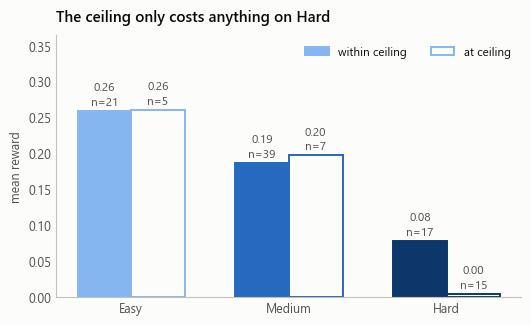

In [6]:
import numpy as np

df = ja.load_job(JOB, solved_at=SOLVED_AT)
t = TEXT["truncation"]

mean = df.pivot_table(index="difficulty", columns="hit_budget", values="reward",
                      aggfunc="mean", observed=True).reindex(ja.LEVELS)
count = df.pivot_table(index="difficulty", columns="hit_budget", values="reward",
                       aggfunc="size", observed=True).reindex(ja.LEVELS)
x = np.arange(len(ja.LEVELS))
width = 0.34

fig, ax = plt.subplots(figsize=(6.0, 3.4))
for offset, cut in ((-width / 2, False), (width / 2, True)):
    values = mean[cut]
    # Solid = the reply finished; hollow = it was cut off. Fill treatment rather
    # than a second colour, so the difficulty ramp keeps its one meaning.
    bars = ax.bar(
        x + offset, values, width, label=t["series"][cut],
        color=[jf.SURFACE if cut else jf.BAND_COLOR[d] for d in ja.LEVELS],
        edgecolor=[jf.BAND_COLOR[d] for d in ja.LEVELS], linewidth=1.4, zorder=2,
    )
    for rect, value, n in zip(bars, values, count[cut]):
        ax.annotate(
            f"{value:.2f}\nn={int(n)}",
            xy=(rect.get_x() + rect.get_width() / 2, value), xytext=(0, 4),
            textcoords="offset points", ha="center", fontsize=8.5,
            color=jf.INK_2, linespacing=1.3,
        )

ax.set_title(t["title"])
ax.set_ylabel(t["y"])
ax.set_ylim(0, mean.to_numpy().max() * 1.4)
ax.set_xticks(x)
ax.set_xticklabels(ja.LEVELS)
ax.legend(loc="upper right", ncol=2)
jf.tidy(ax)
save(fig, "truncation-effect")
plt.show()

## 6. What the tokens bought

Cost per trial spans an order of magnitude, and it is driven by the same thing reward
is: task size. That is the wrong way round for a budget. Sorting the trials into four
equal groups by what they consumed puts the two halves of the problem side by side —
the heaviest quarter returns the least reward *and* uses most of the tokens.

Tokens rather than dollars throughout: a bill depends on which model was priced and on
how much input was served from cache at a discount, and neither is a property of the
method. `cost_usd` is still on the frame for anyone who wants it.

wrote docs\figures\single-shot-token-quartiles.png


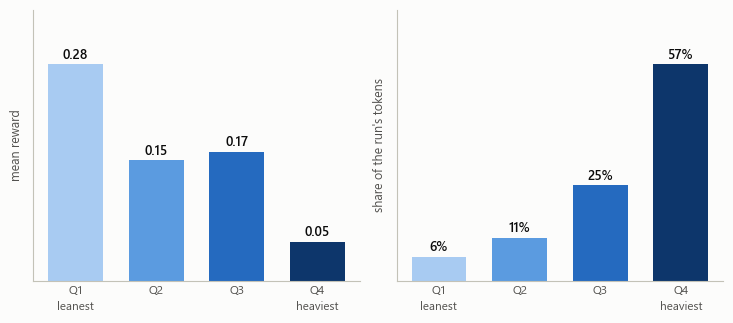

              mean_reward   tokens   n  share
quartile                                     
Q1\nleanest         0.278   458973  26  0.063
Q2                  0.155   826883  26  0.113
Q3                  0.165  1842961  26  0.252
Q4\nheaviest        0.050  4196875  26  0.573

            trials  median_tok  mean_reward
difficulty                                 
Easy            26     19602.0       0.2596
Medium          46     38274.0       0.1886
Hard            32    146213.0       0.0441

Hard against Easy: median tokens x7.5, mean reward x0.17


In [7]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.token_quartiles(df), "token-quartiles")
plt.show()

print(ja.token_quartile_table(df).round(3).to_string())
print()

levels = ja.by_difficulty(df)
print(levels.round(4).to_string())
print()
# Stated as a ratio in a fixed direction rather than as "more" or "less": not
# every arm consumes more on the harder half, and one of them consumes less.
tok = levels.median_tok["Hard"] / levels.median_tok["Easy"]
reward = levels.mean_reward["Hard"] / levels.mean_reward["Easy"]
print(f"Hard against Easy: median tokens x{tok:.1f}, mean reward x{reward:.2f}")

Aggregating the same consumption by what it produced gives the figure worth quoting:
most of the run's tokens went to trials that ended with no passing test at all.

wrote docs\figures\single-shot-tokens-by-outcome.png


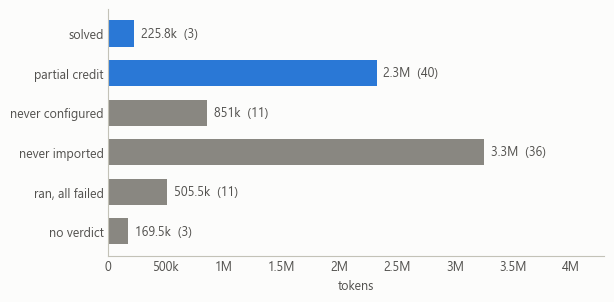

In [8]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.tokens_by_outcome(df), "tokens-by-outcome")
plt.show()

## 7. Why each zero was a zero

"Scored nothing" is not a diagnosis. The verifier writes a full pytest report for every
trial, and that report names the exception that stopped the run — so each zero can be
given the technical reason it earned, read from its own output rather than assigned by
hand. `ja.classify_zero` does this identically for every arm.

Each zero gets a **stage** and a **cause**. The stage is how far the pipeline got:

| Stage | Meaning |
| --- | --- |
| `never configured` | pytest refused to start — unparsable `pyproject.toml`, a config option needing a plugin that is not installed, an incompatible plugin, or no tests collected at all |
| `never imported` | pytest started, and the generated code failed to import |
| `ran, all failed` | the code imported, the tests executed, and every one of them failed |
| `no verdict` | the tester never produced a real judgement — a harness fault, not a finding about the code |

The cause is the exception itself. Two of them are refined further, because the
exception name on its own hides the mistake:

- **`ModuleNotFoundError`** is four different errors. *Own code, wrong layout* — the
  file is in the workspace, but not importable under the name its own code uses.
  *A file it never wrote* — the package is there, the module it imports is not.
  *Uninstalled dependency* — a third-party library the agent assumed would be present.
  *Project built one level too deep* — the whole project sits inside a single
  sub-directory of the workspace. Which one is decided by looking the missing name up
  against everything the agent actually wrote, as a dotted path resolved against both
  import roots and, failing that, against a nested project root.
- **`ImportError`** is three more: a *circular import*; a name *missing from its own
  module*; and a name *gone from an installed module*, which means the code was written
  against an API the installed version does not have.

Where one report holds several exceptions, the cause is the one raised most often — the
error blocking most of the suite, not whichever pytest printed first.

One category cannot occur in this arm and is worth saying so about: *project built one
level too deep* needs an agent that chooses a working directory, and a single-shot reply
writes each file to a path it names. The classifier still reports it, because the same
code reads the agent-loop arms.

wrote docs\figures\single-shot-zero-causes.png


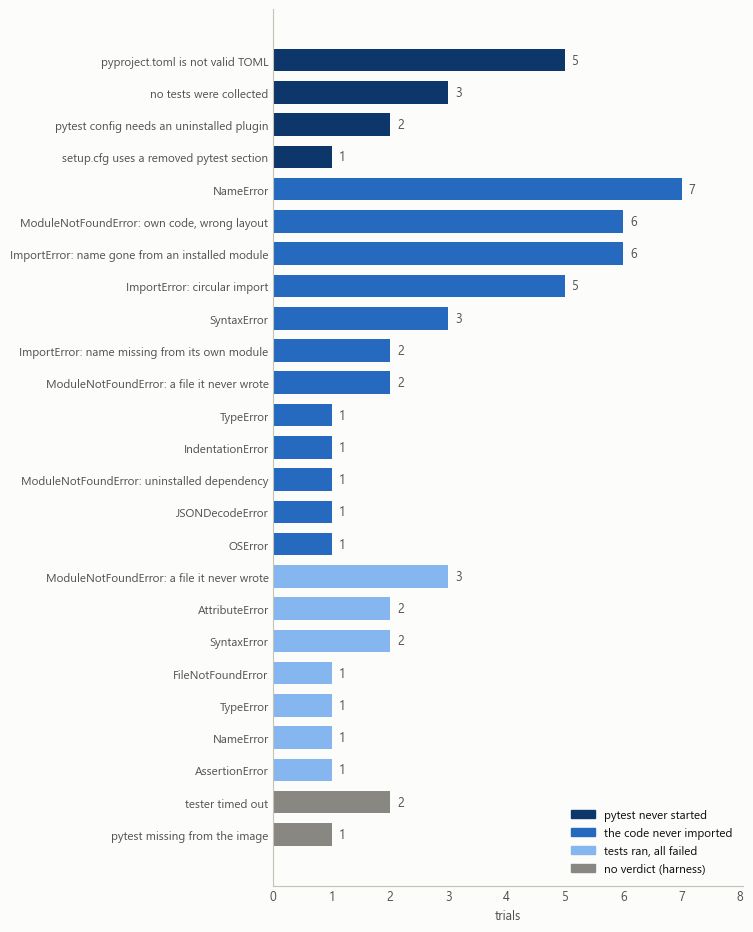

fault_stage
never configured    11
never imported      36
ran, all failed     11
no verdict           3


In [9]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.zero_causes(df), "zero-causes")
plt.show()

zeros = df[df.scored & (df.reward == 0)]
print(zeros.fault_stage.value_counts().reindex(ja.STAGES).fillna(0).astype(int).to_string())

The task behind each row is worth having to hand when reading the figure, so the full
list is printed below.

In [10]:
import pandas as pd

df = ja.load_job(JOB, solved_at=SOLVED_AT)
zeros = df[df.scored & (df.reward == 0)]

table = (zeros[["task", "difficulty", "fault_stage", "fault_cause", "hit_budget"]]
         .sort_values(["fault_stage", "fault_cause", "task"])
         .reset_index(drop=True))
with pd.option_context("display.max_rows", None, "display.width", 210,
                       "display.max_colwidth", 44):
    print(table.to_string())

print()
print("what the reply parser complained about, over all trials")
print(f"  file blocks never closed : {int(df.w_unclosed.sum())}")
print(f"  file blocks left empty   : {int(df.w_empty.sum())}")
print(f"  paths written twice      : {int(df.w_dupe.sum())}")
print(f"  sections with no fence   : {int(df.w_nofence.sum())}")
complaints = df[["w_unclosed", "w_empty", "w_dupe", "w_nofence"]]
print(f"  trials with at least one : {int((complaints.sum(axis=1) > 0).sum())} of {len(df)}")

                     task difficulty       fault_stage                                      fault_cause  hit_budget
0                 sklearn       Easy  never configured                          no tests were collected       False
1                    tqdm       Hard  never configured                          no tests were collected        True
2              voluptuous     Medium  never configured                          no tests were collected       False
3                   emoji     Medium  never configured                 pyproject.toml is not valid TOML       False
4                   jinja       Hard  never configured                 pyproject.toml is not valid TOML        True
5               structlog       Hard  never configured                 pyproject.toml is not valid TOML       False
6               synthetic       Hard  never configured                 pyproject.toml is not valid TOML        True
7       typing_extensions     Medium  never configured                 p

## 8. Two checks on the numbers above

**The reward is what it claims to be.** Reward arrives as a single float in
`result.json`, computed inside the container by a tester this notebook never sees. It
should be the fraction of hidden tests that passed, and pytest's own summary line —
parsed independently, out of a different file — agrees with it closely. The residual
gap is that pytest counts a collection error as one unit where the tester counts the
tests it would have contained.

**Every zero was classified, and none was left over.** A zero the classifier could not
read would be filed as `unclassified`, and the count of those is printed below, so that
a silent gap in the taxonomy cannot pass as a clean result.

In [11]:
import pandas as pd

df = ja.load_job(JOB, solved_at=SOLVED_AT)

ran = df[df.scored & df.pt_ran].copy()
units = (ran.pt_passed + ran.pt_failed + ran.pt_error).replace(0, pd.NA)
ran["pytest_fraction"] = ran.pt_passed / units
agree = ran.dropna(subset=["pytest_fraction"])

print("reward against pytest's own pass fraction")
print(f"  trials compared : {len(agree)} of {int(df.scored.sum())} scored"
      f" ({int(df.scored.sum()) - len(ran)} excluded, pytest never reached a summary)")
print(f"  correlation     : r = {agree.reward.corr(agree.pytest_fraction):.3f}")
print(f"  median gap      : {(agree.reward - agree.pytest_fraction).abs().median():.3f}")
print()

zeros = df[df.scored & (df.reward == 0)]
print(f"unclassified zeros: {int((zeros.fault_cause == 'unclassified').sum())} of {len(zeros)}")
print()
print("how the run stopped, and what each way scored")
print(df.groupby("ending").agg(
    trials=("reward", "size"), mean_reward=("reward", "mean"),
    zeros=("reward", lambda s: int((s == 0).sum()))).round(3).to_string())

reward against pytest's own pass fraction
  trials compared : 78 of 104 scored (23 excluded, pytest never reached a summary)
  correlation     : r = 0.972
  median gap      : 0.000

unclassified zeros: 0 of 61

how the run stopped, and what each way scored
                           trials  mean_reward  zeros
ending                                               
cut at the output ceiling      27        0.102     19
reply finished                 77        0.183     42


## What this run says

- **The floor is low and lopsided.** The mean reward is 0.16, but the median trial
  scores nothing and only a handful of tasks are solved outright. A method compared
  against this baseline should be compared on the whole distribution, not the mean.
- **Difficulty dominates everything else.** Easy to Hard is roughly a six-fold drop in
  reward and a steep rise in median tokens, in the same direction — so a comparison
  run on a difficulty-skewed subset of tasks will read very differently from one run on
  the full benchmark. That is the case for the balanced subset selected in
  `nl2repobench-subset-selection.ipynb`.
- **The output ceiling binds on Hard, and only there.** Nearly half of Hard replies are
  cut off, and those score essentially nothing, while truncation on Easy and Medium
  costs nothing measurable. Raising `max_tokens` would move that — though five of the
  truncated replies were degenerate repetition, and more room buys those nothing.
- **Most of the tokens bought no passing test.** Most went to large tasks a
  single request was never going to complete, which is the argument for spending the
  budget on iteration rather than on one very long reply.
- **Most zeros are mechanical, not conceptual.** The largest group of zeros is code that
  never imported — circular imports, files the reply named but never wrote, packages
  laid out where nothing can import them — and a further group is projects pytest
  refused to configure. Only a minority are runs where the tests executed and the
  answers were wrong.